In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import colormaps
import geopandas as gpd
import numpy as np
import xarray as xr
import rioxarray as rxr
import codebase

Notes:
- Neches is a triburtary of Sabine river. Number of dams is one more than the number of basins.

In [2]:
grdc_dir = "/global/scratch/users/ann_scheliga/aux_dam_datasets/GRDC_CRB/"
res_dir = "/global/scratch/users/ann_scheliga/CYGNSS_daily/time_series/"

In [3]:
res_shp = codebase.load_data.load_GRanD()
subregions_meta = gpd.read_file(grdc_dir + 'subregions.geojson')

In [4]:
site_series = pd.read_json('../dam_basin_pair.json',typ='series')

In [5]:
site_stations = gpd.read_file(grdc_dir+'site_stationbasins.geojson')
site_stations.set_index(site_stations['grdc_no'].astype(int),inplace=True)

In [6]:
dam_names = [item.replace('_',' ') for item in list(site_series)]
dam_shps = res_shp[res_shp['DAM_NAME'].str.lower().isin(dam_names)]

## Create panel of maps

In [7]:
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

/tmp/ipykernel_2530971/3912264495.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


In [8]:
site_stations['lat_lon'] = gpd.points_from_xy(y =site_stations['lat_org'], x =  site_stations['long_org'])
stations_points = site_stations.set_geometry('lat_lon', crs = "EPSG:4326")

In [9]:
site_stations.columns

Index(['grdc_no', 'river', 'station', 'area', 'altitude', 'lat_org',
       'long_org', 'lat_pp', 'long_pp', 'dist_km', 'area_calc', 'quality',
       'type', 'comment', 'source', 'geometry', 'lat_lon'],
      dtype='object')

In [10]:
dam_shps.columns

Index(['GRAND_ID', 'RES_NAME', 'DAM_NAME', 'ALT_NAME', 'RIVER', 'ALT_RIVER',
       'MAIN_BASIN', 'SUB_BASIN', 'NEAR_CITY', 'ALT_CITY', 'ADMIN_UNIT',
       'SEC_ADMIN', 'COUNTRY', 'SEC_CNTRY', 'YEAR', 'ALT_YEAR', 'REM_YEAR',
       'DAM_HGT_M', 'ALT_HGT_M', 'DAM_LEN_M', 'ALT_LEN_M', 'AREA_SKM',
       'AREA_POLY', 'AREA_REP', 'AREA_MAX', 'AREA_MIN', 'CAP_MCM', 'CAP_MAX',
       'CAP_REP', 'CAP_MIN', 'DEPTH_M', 'DIS_AVG_LS', 'DOR_PC', 'ELEV_MASL',
       'CATCH_SKM', 'CATCH_REP', 'DATA_INFO', 'USE_IRRI', 'USE_ELEC',
       'USE_SUPP', 'USE_FCON', 'USE_RECR', 'USE_NAVI', 'USE_FISH', 'USE_PCON',
       'USE_LIVE', 'USE_OTHR', 'MAIN_USE', 'LAKE_CTRL', 'MULTI_DAMS',
       'TIMELINE', 'COMMENTS', 'URL', 'QUALITY', 'EDITOR', 'LONG_DD', 'LAT_DD',
       'POLY_SRC', 'geometry'],
      dtype='object')

In [11]:
basin_bbox = site_stations.iloc[[0],:].bounds.values[0]

In [12]:
import geodatasets
import contextily as cx

In [13]:
cmap_colors = colormaps['tab20'].colors

basin_green = cmap_colors[5]
res_blue = cmap_colors[0]
station_orange = cmap_colors[6]


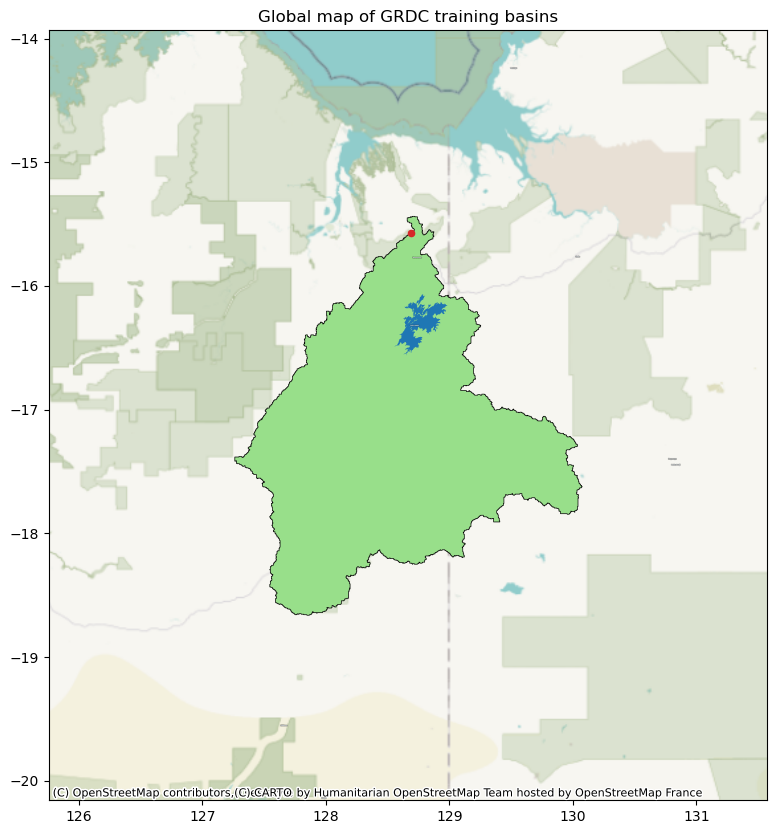

In [19]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()

ax.set_xlim([basin_bbox[0]-1.5,basin_bbox[2]+1.5])
ax.set_ylim([basin_bbox[1]-1.5,basin_bbox[3]+1.5])

site_stations.iloc[[0],:].plot(ax=ax,color=basin_green,edgecolor='black',linewidth=0.5)
stations_points.iloc[[0],:].plot(ax=ax,color=station_orange,edgecolor=station_orange,markersize=20)
dam_shps.plot(ax=ax, color= res_blue)

cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels)
cx.add_basemap(ax,crs=site_stations.crs, source=cx.providers.CartoDB.PositronOnlyLabels,zoom=10)
# set the plot title
plt.title("Global map of GRDC training basins")
plt.show()
# plt.savefig('./global_grdc_basin_map.png')